# Лабораторна робота №3: Візуалізація даних

## Хід виконання роботи
1. **Обрати унікальний датасет** (обрано: *UCI Automobile Dataset*, ID: 10), який містить категоріальні, цілі та дійсні числа, а також пропущені значення.
2. **Здійснити Data Cleaning** (обробка знаків `?`, заповнення числових пропусків медіаною, а категоріальних — модою).
3. **Побудувати графіки залежності** числових атрибутів.
4. **Побудувати гістограму** з розподілом елементів за 5-ма фіксованими діапазонами.
5. **Візуалізувати багатовимірні дані** (згідно з методологією статті з Medium).
6. **Загальна кількість графіків:** 6 (в межах ліміту 5-8).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 

# Налаштування стилів візуалізації
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Завантаження датасету Automobile (UCI ID: 10)
automobile = fetch_ucirepo(id=10) 
X = automobile.data.features 
y = automobile.data.targets 

# Об'єднуємо фічі та таргет в один DataFrame
df = pd.concat([X, y], axis=1)

print(f"Розмірність завантаженого датасету: {df.shape}")
df.head()

Розмірність завантаженого датасету: (205, 26)


,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,...,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses,symboling
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN,3
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,...,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN,1
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,...,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0,2
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,...,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0,2


### Етап 1: Data Cleaning (Очищення даних)
**Умова:** Виявити пропущені значення, замінити нетипові символи `?` на `NaN`, виконати імпутацію пропусків (для числових — медіана, для категоріальних — мода).


In [5]:
# Замінюємо символи '?' на стандартні NaN
df.replace('?', np.nan, inplace=True)

print("Пропущені значення до очищення:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Перелік числових колонок, які містили пропуски або неправильний тип
numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']

# Перетворюємо їх на числовий формат (errors='coerce' перетворить помилки на NaN)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Заповнюємо числові пропуски медіаною
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Заповнюємо категоріальні пропуски модою (найбільш частотним значенням)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nКількість пропусків після Data Cleaning:", df.isnull().sum().sum())

Пропущені значення до очищення:
price                 4
peak-rpm              2
horsepower            2
stroke                4
bore                  4
num-of-doors          2
normalized-losses    41
dtype: int64

Кількість пропусків після Data Cleaning: 0


### Етап 2: Побудова графіків залежності (Lineplot / Scatter / Regplot)
**Графік 1:** Залежність ціни автомобіля від його потужності (`Horsepower vs Price`) з лінією тренду для демонстрації кореляції.

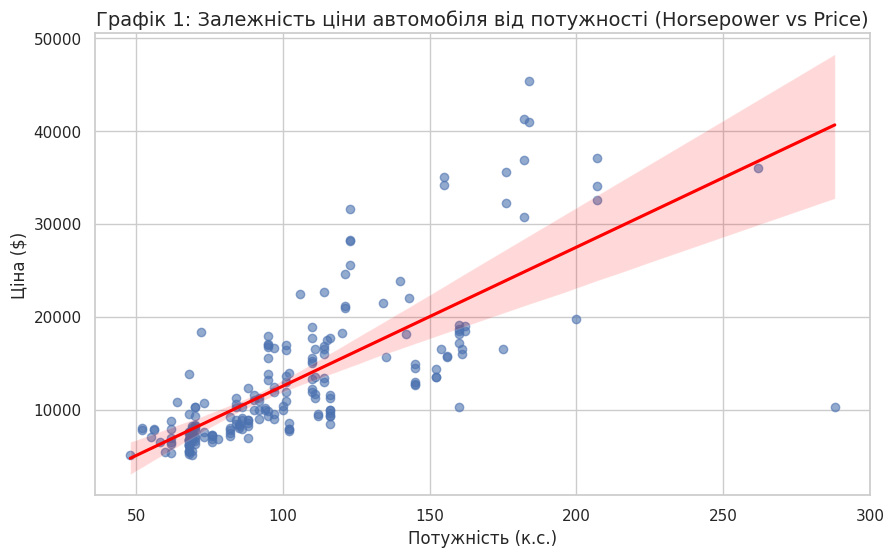

In [6]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='horsepower', y='price', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

plt.title('Графік 1: Залежність ціни автомобіля від потужності (Horsepower vs Price)', fontsize=14)
plt.xlabel('Потужність (к.с.)')
plt.ylabel('Ціна ($)')
plt.show()

### Етап 3: Гістограма по одному з атрибутів (5 заданих діапазонів)
**Графік 2:** Розподіл автомобілів за потужністю двигуна в межах 5 вручну заданих інтервалів: `[40, 80]`, `[80, 120]`, `[120, 160]`, `[160, 200]`, `[200, 260]`.

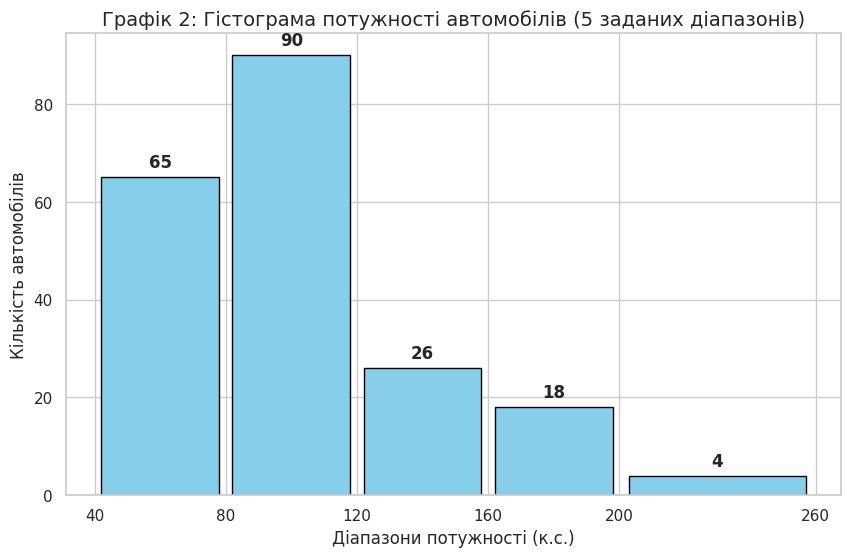

In [7]:
custom_bins = [40, 80, 120, 160, 200, 260]
plt.figure(figsize=(10, 6))

n, bins, patches = plt.hist(df['horsepower'], bins=custom_bins, color='skyblue', edgecolor='black', rwidth=0.9)

# Додаємо числові значення над кожним стовпчиком гістограми
for i in range(len(n)):
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, n[i] + 2, str(int(n[i])), ha='center', fontweight='bold')

plt.title('Графік 2: Гістограма потужності автомобілів (5 заданих діапазонів)', fontsize=14)
plt.xlabel('Діапазони потужності (к.с.)')
plt.ylabel('Кількість автомобілів')
plt.xticks(custom_bins)
plt.show()

### Етап 4: Ефективна візуалізація багатовимірних даних (The Art of Effective Visualization)
**Графік 3 (4-мерне відображення):** Одночасна візуалізація колісної бази (`x`), ціни (`y`), типу палива (`hue`) та потужності (`size`), згідно з концепціями статті Medium.

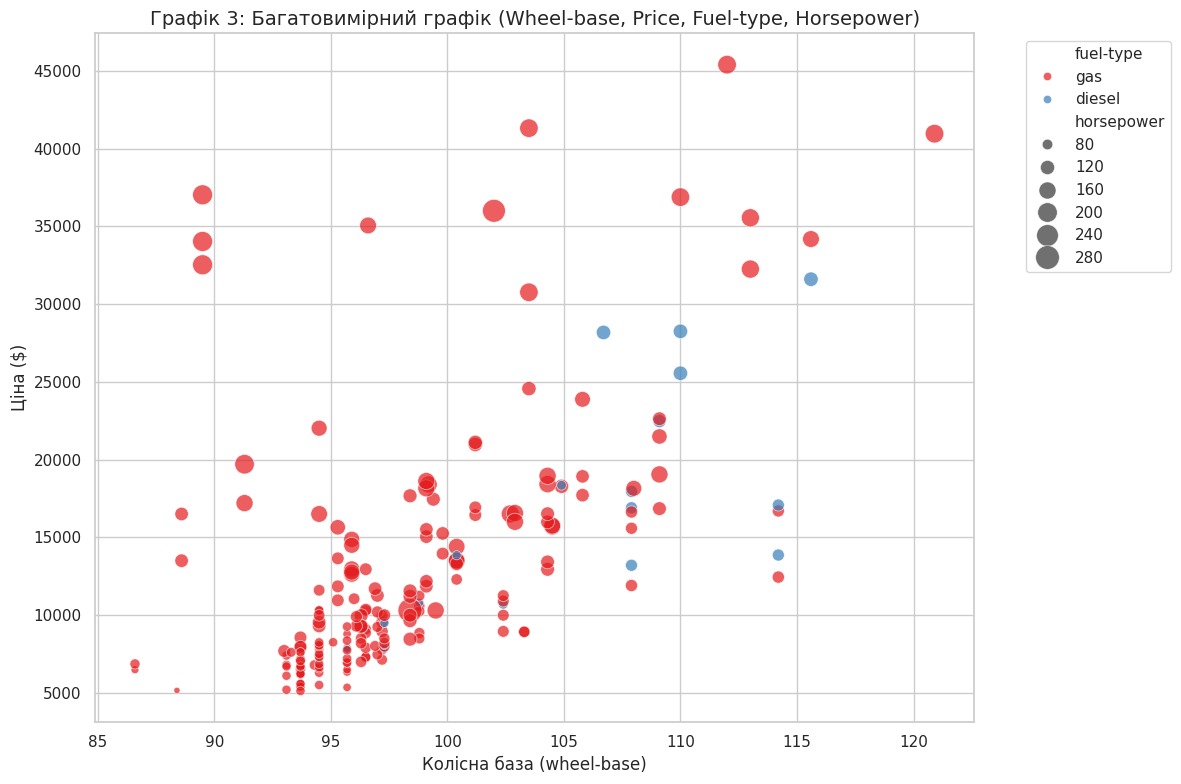

In [8]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='wheel-base', 
    y='price', 
    hue='fuel-type',     
    size='horsepower',   
    sizes=(20, 300), 
    alpha=0.7, 
    palette='Set1'
)

plt.title('Графік 3: Багатовимірний графік (Wheel-base, Price, Fuel-type, Horsepower)', fontsize=14)
plt.xlabel('Колісна база (wheel-base)')
plt.ylabel('Ціна ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Етап 5: Додаткові графіки для аналізу корисних інсайтів
**Графік 4:** Аналіз розподілу цін залежно від типу кузова автомобіля за допомогою `boxplot` (діаграма розмаху).

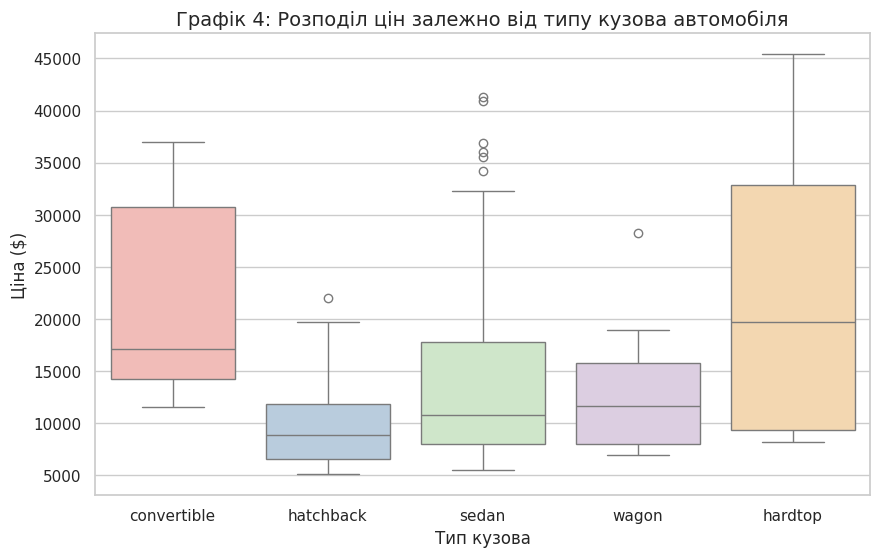

In [9]:
plt.figure(figsize=(10, 6))
# Передаємо hue='body-style' для уникнення попереджень у нових версіях Seaborn
sns.boxplot(data=df, x='body-style', y='price', hue='body-style', palette='Pastel1', legend=False)

plt.title('Графік 4: Розподіл цін залежно від типу кузова автомобіля', fontsize=14)
plt.xlabel('Тип кузова')
plt.ylabel('Ціна ($)')
plt.show()

**Графік 5:** Теплокарта кореляцій матриці (`Heatmap`) для ключових числових параметрів автомобіля. Дозволяє виявити мультиколінеарність.

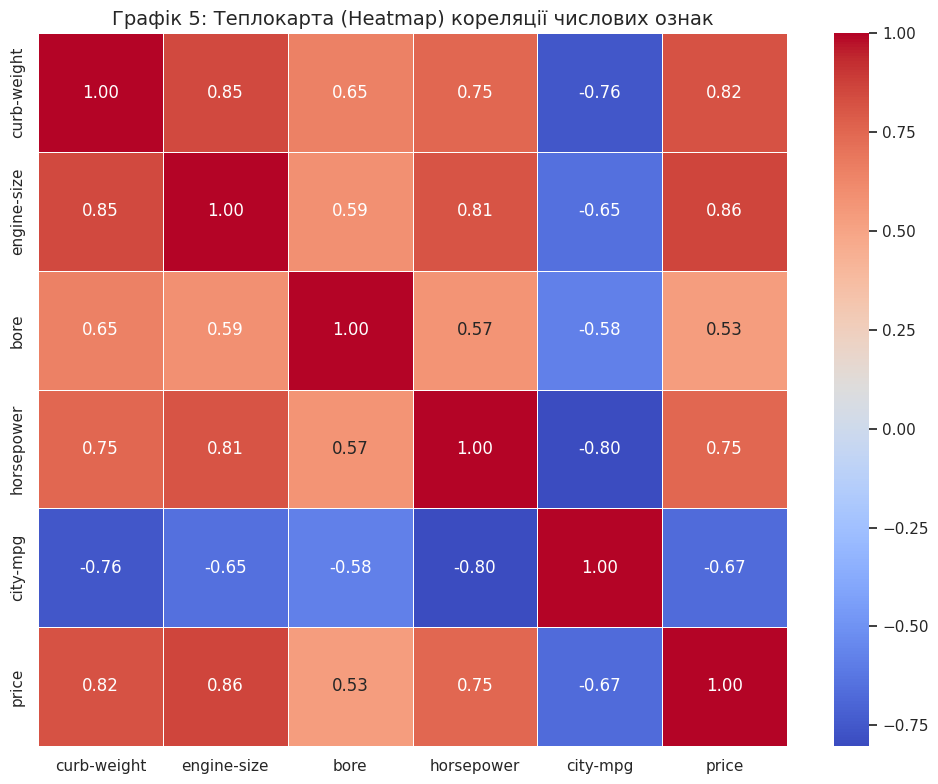

In [10]:
plt.figure(figsize=(10, 8))
selected_features = df[['curb-weight', 'engine-size', 'bore', 'horsepower', 'city-mpg', 'price']]
correlation_matrix = selected_features.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Графік 5: Теплокарта (Heatmap) кореляції числових ознак', fontsize=14)
plt.tight_layout()
plt.show()

**Графік 6:** Скрипковий графік (`Violinplot`) для відображення щільності розподілу потужності двигуна на основі типу приводу автомобіля. 


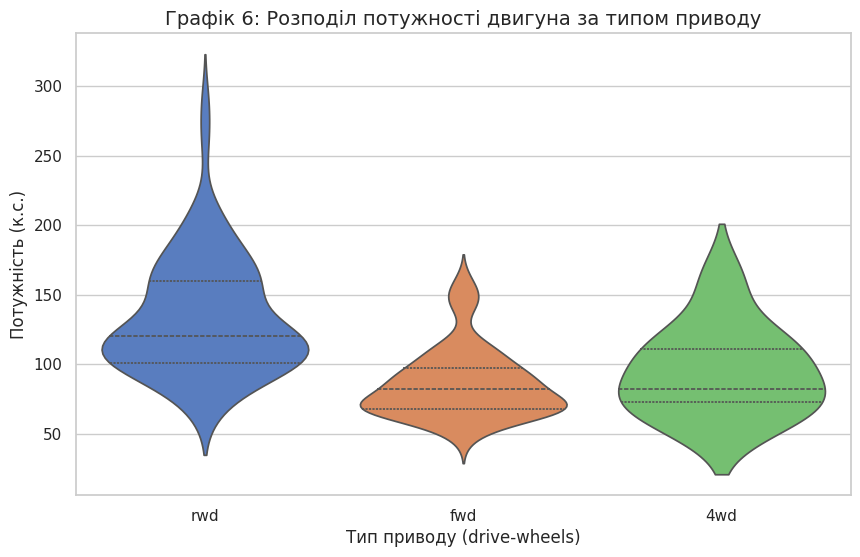

In [11]:
plt.figure(figsize=(10, 6))
# Виправлено FutureWarning через додавання hue='drive-wheels' та відключення легенди
sns.violinplot(data=df, x='drive-wheels', y='horsepower', hue='drive-wheels', palette='muted', inner='quartile', legend=False)

plt.title('Графік 6: Розподіл потужності двигуна за типом приводу', fontsize=14)
plt.xlabel('Тип приводу (drive-wheels)')
plt.ylabel('Потужність (к.с.)')
plt.show()